In [1]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
from transformers import BertTokenizer, BertModel
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# === CONFIG ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_dir = "../dataset/spectograms/mel_graphic"
text_dir = "../dataset/Lyrics"
classes_path = "../dataset/classes.txt"
batch_size = 32
num_epochs = 10

In [3]:
# === LABELS ===
with open(classes_path, "r") as f:
    class_lines = [line.strip() for line in f.readlines()]  # np. ["positive", "negative", "positive", ...]

# Zidentyfikuj unikalne klasy i przypisz im liczby
unique_classes = sorted(set(class_lines))  # ['hateful', 'negative', 'positive'] np.
class_to_idx = {cls: idx for idx, cls in enumerate(unique_classes)}  # {'hateful': 0, 'negative': 1, 'positive': 2}

# labels_dict: klucz to ID (str), wartość to indeks klasy (int)
labels_dict = {str(i): class_to_idx[class_lines[i]] for i in range(len(class_lines))}

print("Znalezione klasy:", class_to_idx)


Znalezione klasy: {'negative': 0, 'nostalgic': 1, 'positive': 2}


In [4]:
unique_classes

['negative', 'nostalgic', 'positive']

In [5]:
from pathlib import Path

class MultimodalDataset(Dataset):
    def __init__(self, image_dir, text_dir, labels_dict, tokenizer, transform=None):
        self.image_dir = Path(image_dir)
        self.text_dir = Path(text_dir)
        self.labels_dict = labels_dict
        self.tokenizer = tokenizer
        self.transform = transform
        self.file_ids = list(labels_dict.keys())

    def __getitem__(self, idx):
        file_id = self.file_ids[idx]
        label = self.labels_dict[file_id]

        # === OBRAZ ===
        image_path = self.image_dir / f"{int(file_id) + 1:03d}_mel.png"


        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # === TEKST ===
        text_path = self.text_dir / (file_id + ".txt")

        if text_path.exists():
            with open(text_path, 'r', encoding='utf-8') as f:
                text = f.read()
        else:
            text = ""  # lub np. "[NO TEXT]" jeśli chcesz oznaczyć brak tekstu
            
        encoding = self.tokenizer(text, padding='max_length', truncation=True, max_length=128, return_tensors='pt')

        return {
            'image': image,
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

    def __len__(self):
        return len(self.file_ids)


In [6]:
# === TRANSFORMS & TOKENIZER ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [7]:
file_ids = list(labels_dict.keys())
labels = list(labels_dict.values())

In [ ]:
# === DATA ===
full_dataset = MultimodalDataset(image_dir, text_dir, labels_dict, tokenizer, transform)

total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [9]:
len(full_dataset)

903

In [10]:
len(train_loader), len(val_loader), len(test_loader)

(20, 6, 3)

In [11]:
# === MODEL ===
class MultimodalClassifier(nn.Module):
    def __init__(self, num_classes):
        super(MultimodalClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.cnn = models.regnet_y_800mf(weights=models.RegNet_Y_800MF_Weights.DEFAULT)
        self.cnn.fc = nn.Identity()  # remove classification layer

        self.fc = nn.Sequential(
            #nn.Linear(1208, 512), # dla 400
            nn.Linear(768 + 784, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )


    def forward(self, input_ids, attention_mask, images):
        text_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_feat = text_output.pooler_output  # shape: (B, 768)

        image_feat = self.cnn(images)  # shape: (B, 1000)

        combined = torch.cat((text_feat, image_feat), dim=1)
        out = self.fc(combined)
        return out

In [12]:
# === TRAINING ===
model = MultimodalClassifier(num_classes=len(unique_classes)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

    # Walidacja
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Validation Accuracy: {correct/total:.4f}")

Epoch 1/10, Loss: 1.0210
Validation Accuracy: 0.5778
Epoch 2/10, Loss: 0.7839
Validation Accuracy: 0.5944
Epoch 3/10, Loss: 0.4849
Validation Accuracy: 0.5778
Epoch 4/10, Loss: 0.1994
Validation Accuracy: 0.5722
Epoch 5/10, Loss: 0.0716
Validation Accuracy: 0.5611
Epoch 6/10, Loss: 0.0310
Validation Accuracy: 0.5944
Epoch 7/10, Loss: 0.0128
Validation Accuracy: 0.6167
Epoch 8/10, Loss: 0.0182
Validation Accuracy: 0.6000
Epoch 9/10, Loss: 0.0096
Validation Accuracy: 0.6167
Epoch 10/10, Loss: 0.0065
Validation Accuracy: 0.5556


In [13]:


# === TEST ===
from sklearn.metrics import classification_report

model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask, images)
        preds = torch.argmax(outputs, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

print("\nTest classification report:")
print(classification_report(test_labels, test_preds, target_names=unique_classes))




Test classification report:
              precision    recall  f1-score   support

    negative       0.53      0.41      0.46        22
   nostalgic       0.65      0.86      0.74        28
    positive       0.68      0.61      0.64        41

    accuracy                           0.64        91
   macro avg       0.62      0.63      0.61        91
weighted avg       0.63      0.64      0.63        91



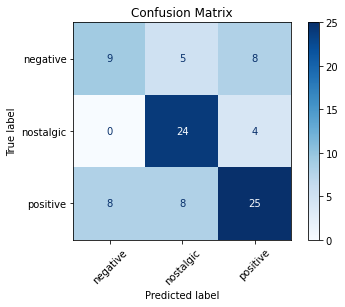

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# === CONFUSION MATRIX ===
cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
